In [1]:
import pandas as pd
import geopandas as gpd

import os, sys, importlib, warnings, pathlib
from pathlib import Path
sys.path.append(os.path.abspath(".."))
warnings.filterwarnings("ignore",category=FutureWarning)

# my utils
from utils import split_listings
from utils import preprocess_listings
from utils import geoplot

In [11]:
importlib.reload(split_listings)
from utils.split_listings import split_change_stable
path_Q1="../data_listings\listings_paris2403.csv"
path_Q2="../data_listings\listings_paris2406.csv"
dfQ2=split_change_stable(path_Q1, path_Q2, year=2024, 
                       threshold_text_sim=0.85, 
                       save=True,
                       output_folder="../data_listings")

[IO] input :dfQ2.csv => outupt:dfQ2_split.csv
===================================INPUT DATA===================================
len df Q1: 84397
len df Q2: 95885
len df total : 180282 

---------------------------------------listings count change----------------------------------------
new listings in Q2 19299(20.13%)
listings dispeared in Q2 : 7811(8.15%)
listings changed (in+out) in Q2:27110

---------------------------------------------BIO change---------------------------------------------
---------------------------------------------PIC change---------------------------------------------
----------------------------------number of reviews till previousQ----------------------------------
----------------------------------split  changed and stable hosts-----------------------------------
[INFO] 4 criterions : 
- NEW hosts enter between '2024-01-01'~'2024-06-30';
- REACTIVED hosts : host_since before Q1+Q2; active not in Q1, but in Q2 ;
- REOPEN host: ava90_previousQ==0, ava90!=0 => A

d:\Edu\Multilevel_Geovisualisaiton_Airbnb_JO\utils\split_listings.py:227: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['status_changed'] = (
d:\Edu\Multilevel_Geovisualisaiton_Airbnb_JO\utils\split_listings.py:232: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sp_changed'] = (
d:\Edu\Multilevel_Geovisualisaiton_Airbnb_JO\utils\split_listings.py:238: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See

[INFO] OVERALL changed : 37304; stable : 58581
 changed : 0.39%; stable : 0.61%

----------------------------------------------------------------------------------------------------
booking_rate_l90d :
[info] 
no match/no ava: booking_rate_l90d_previousQ
True     0.558732
False    0.441268
Name: count, dtype: float64
count    42311.000000
mean         0.160410
std          0.271851
min          0.000000
25%          0.000000
50%          0.033898
75%          0.178571
max          1.000000
Name: booking_rate_l90d_previousQ, dtype: float64

[RUNTIME] done in 14.66 sec!
✅[SAVE] dfQ2 split saved to ../data_listings\listings_paris2406_split.csv!


In [ ]:
##  preprocess data2406
importlib.reload(preprocess_listings)
from utils.preprocess_listings import preprocess_host_variables, preprocess_obj_vars, keep_cols

#===================================df==============================================
path_2406="../data_listings\listings_paris2406_split.csv"
df=pd.read_csv(path_2406)

path_2409="../data_listings/listings_paris2409.csv"
df_nextQ=pd.read_csv(path_2409)

OUPUT_FOLDER_PROCESSED='../data_processed/with_reviews_nextQ'

#----------------------------process+filter+simplify-------------------------------

df_processed=preprocess_host_variables(df)
df_filtered=preprocess_obj_vars(df=df_processed, df_nextQ=df_nextQ,
                        proxy_vars=['price',"availability_30","availability_90"], 
                        get_booking_rate_l30d=False, filtrate_by_booking_rate_l30d=False, 
                        get_booking_rate_l90d=True, filtrate_by_booking_rate_l90d=True,
                        obj_vars=["room_type","instant_bookable"],#"minimum_nights"关系不大？ 
                        threshold_km=1, 
                        output_folder=OUPUT_FOLDER_PROCESSED, filename=f"listings_paris2406_filtered.csv")

C:\Users\yeliu\AppData\Local\Temp\ipykernel_4048\1113656849.py:33: DtypeWarning: Columns (77,79) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(path_2406)




******************************HOST VARS******************************
PROCESS PIPELINE :
- host_has_profile_pic : fillna('f') if not f/t
- host_identity_verified: fillna('f') if not f/t 
- host_is_sueprhost: check ONLY 't'/'f'; fillna('f')
- review_scores_rating: 34.0% NaN; fillna(mean), to numeric; ADD 'has_rating' 
- host_since: ADD 'years_since_host' :float, 0.5-1 year=>1， 0-0.5 year => 0 
- has_host_about: 'lang:en/fr/other_langs','len:int',
- host_response_time:40.0% NaN, fillna('no_response_time') 
- host_response_rate:40.0% NaN, ADD 'has_response_rate' :1/0， fillna(0)
- calculated_host_listings_count : ADD 'professional_host:1/0', count>1

[INFO] missing review scores are filled by mean :4.724711210889053

==========================HOST VARS================================
16 IMPO VARS:['host_picture_url', 'host_identity_verified', 'number_of_reviews', 'host_is_superhost', 'review_scores_rating', 'has_rating', 'host_since', 'years_since_host', 'host_about', 'lang', 'len', 'hos

In [ ]:
print(len(df_filtered))
print(df_filtered.status.value_counts(dropna=False)/len(df_filtered),"\n")
print(df_filtered.status.value_counts(dropna=False))

62738
status
old_host         0.636281
reopen_host      0.185932
reactive_host    0.143438
new_host         0.034349
Name: count, dtype: float64 

status
old_host         0.636281
reopen_host      0.185932
reactive_host    0.143438
new_host         0.034349
Name: count, dtype: float64


In [ ]:
df_filtered=pd.read_csv(f"../data_processed/with_reviews_nextQ/listings_paris2406_filtered.csv")
print(len(df_filtered))#+status

C:\Users\yeliu\AppData\Local\Temp\ipykernel_19084\2819891054.py:1: DtypeWarning: Columns (77,79) have mixed types. Specify dtype option on import or set low_memory=False.
  df_filtered=pd.read_csv(f"../data_processed/with_reviews_nextQ/listings_paris2406_filtered.csv")


62738


## preprocess_listings: 24Q1 Q3

In [ ]:
## 2403/09 filtré selon la booing90！！

importlib.reload(preprocess_listings)
from utils.preprocess_listings import preprocess_host_variables, preprocess_obj_vars, keep_cols


INPUT_FOLDER_RAW=Path("../data_listings")
dict_paths={"2403": INPUT_FOLDER_RAW/"listings_paris2403.csv",
        "2406": INPUT_FOLDER_RAW/"listings_paris2406_split.csv",
       "2409": INPUT_FOLDER_RAW/"listings_paris2409.csv",
       '2412':INPUT_FOLDER_RAW/"listings_paris2412.csv"}

#----------------------------process-------------------------------
OUPUT_FOLDER_PROCESSED='../data_processed/with_reviews_nextQ'

for ym in ["2403","2409"]:        
    # input
    path=dict_paths[ym]
    df=pd.read_csv(path)

    path_df_nextQ=dict_paths.get(str(int(ym)+3), None)
    df_nextQ=pd.read_csv(path_df_nextQ)
    print(path, path_df_nextQ,"\n")
    
    ## process+filter 
    df_processed=preprocess_host_variables(df)
    df_filtered=preprocess_obj_vars(df=df_processed, df_nextQ=df_nextQ,
                        proxy_vars=['price',"availability_30","availability_90"], 
                        get_booking_rate_l30d=False, filtrate_by_booking_rate_l30d=False,#无输入时默认不按照booking筛选 
                        get_booking_rate_l90d=True, filtrate_by_booking_rate_l90d=True,
                        obj_vars=["room_type","instant_bookable"],#"minimum_nights"关系不大？ 
                        threshold_km=3, 
                        output_folder=OUPUT_FOLDER_PROCESSED, filename=f"listings_paris{ym}_filtered.csv")
    

C:\Users\yeliu\AppData\Local\Temp\ipykernel_4048\1879393368.py:42: DtypeWarning: Columns (77,79) have mixed types. Specify dtype option on import or set low_memory=False.
  df_nextQ=pd.read_csv(path_df_nextQ)


..\data_listings\listings_paris2403.csv ..\data_listings\listings_paris2406_split.csv 



******************************HOST VARS******************************
PROCESS PIPELINE :
- host_has_profile_pic : fillna('f') if not f/t
- host_identity_verified: fillna('f') if not f/t 
- host_is_sueprhost: check ONLY 't'/'f'; fillna('f')
- review_scores_rating: 30.0% NaN; fillna(mean), to numeric; ADD 'has_rating' 
- host_since: ADD 'years_since_host' :float, 0.5-1 year=>1， 0-0.5 year => 0 
- has_host_about: 'lang:en/fr/other_langs','len:int',
- host_response_time:43.0% NaN, fillna('no_response_time') 
- host_response_rate:43.0% NaN, ADD 'has_response_rate' :1/0， fillna(0)
- calculated_host_listings_count : ADD 'professional_host:1/0', count>1

[INFO] missing review scores are filled by mean :4.712363710541077

==========================HOST VARS================================
16 IMPO VARS:['host_picture_url', 'host_identity_verified', 'number_of_reviews', 'host_is_superhost', 'review_scores_ra

## df 2 gdf : 24Q1Q2Q3

In [2]:
import geopandas as gpd
from utils import geoplot
importlib.reload(geoplot)
from utils.geoplot import read_gdf, save_gdf, df2gdf, locate_points

LOC="paris"
YMS=["2403","2406","2409"]

INPUT_FOLDER_PROCESSED=OUPUT_FOLDER_PROCESSED='..\data_processed\with_reviews_nextQ' 
PATH_MAP="../data_map/paris_ar.gpkg"
OUTPUT_FOLDER_GEO="../data_geo/Q1Q2Q3"
CRS="EPSG:4326"


for ym in YMS:   
    print(f'{ym}'.center(100,'=')) 
    path_df_filtered=os.path.join(INPUT_FOLDER_PROCESSED, f"listings_{LOC}{ym}_filtered.csv")
    
    print(path_df_filtered)
    gdf_=locate_points(path_listings=path_df_filtered, path_map=PATH_MAP, 
                    crs=CRS,  
                    save_gdf_joined=True,                     
                    output_folder=OUTPUT_FOLDER_GEO,
                    filename=f'listings_{LOC}{ym}_geo.gpkg')


================================================2403================================================
..\data_processed\with_reviews_nextQ\listings_paris2403_filtered.csv
-----------------------df_listings to gdf_listings by latitude and longitude!-----------------------
[INFO] len df: 40865
default crs 'EPSG:4326'
ADD 'geometry' by latitude and longitude!

--------------------------------------------read gdf map--------------------------------------------
-------------------------------------join gdf_listings and gdf--------------------------------------
☑️ [SAVE] gpkg file saved to ../data_geo/Q1Q2Q3\listings_paris2403_geo.gpkg!
================================================2406================================================
..\data_processed\with_reviews_nextQ\listings_paris2406_filtered.csv
-----------------------df_listings to gdf_listings by latitude and longitude!-----------------------


d:\Edu\Multilevel_Geovisualisaiton_Airbnb_JO\utils\geoplot.py:76: DtypeWarning: Columns (77,79) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(path_listings)


[INFO] len df: 62738
default crs 'EPSG:4326'
ADD 'geometry' by latitude and longitude!

--------------------------------------------read gdf map--------------------------------------------
-------------------------------------join gdf_listings and gdf--------------------------------------
☑️ [SAVE] gpkg file saved to ../data_geo/Q1Q2Q3\listings_paris2406_geo.gpkg!
================================================2409================================================
..\data_processed\with_reviews_nextQ\listings_paris2409_filtered.csv
-----------------------df_listings to gdf_listings by latitude and longitude!-----------------------
[INFO] len df: 48064
default crs 'EPSG:4326'
ADD 'geometry' by latitude and longitude!

--------------------------------------------read gdf map--------------------------------------------
-------------------------------------join gdf_listings and gdf--------------------------------------
☑️ [SAVE] gpkg file saved to ../data_geo/Q1Q2Q3\listings_paris2409_geo.g

## Choropleth

In [4]:
## load:
import os, sys, importlib
from pathlib import Path
import pandas as pd
import geopandas as gpd
sys.path.append(os.path.abspath(".."))
from utils import geoplot
importlib.reload(geoplot)
from utils.geoplot import get_choropleth_map, read_gdf

gdf_joined=read_gdf("../data_geo\Q1Q2Q3\listings_paris2406_geo.gpkg")
gdf_map=read_gdf('../data_map\paris_ar.gpkg')
gdf_venues=gpd.read_file("../data_geo\main_venues_JO.gpkg")

OUTPUT_FOLDER_MAP="../output_map1"

In [27]:
gdf_joined.columns.to_list()

['id',
 'listing_url',
 'scrape_id',
 'last_scraped',
 'source',
 'name',
 'description',
 'neighborhood_overview',
 'picture_url',
 'host_id',
 'host_url',
 'host_name',
 'host_since',
 'host_location',
 'host_about',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_thumbnail_url',
 'host_picture_url',
 'host_neighbourhood',
 'host_listings_count',
 'host_total_listings_count',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bathrooms_text',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'minimum_nights',
 'maximum_nights',
 'minimum_minimum_nights',
 'maximum_minimum_nights',
 'minimum_maximum_nights',
 'maximum_maximum_nights',
 'minimum_nights_avg_ntm',
 'maximum_nights_avg_ntm',
 'calendar_updated',
 'has_availability',
 'availability_30

[INFO] cbar takes bounds: quantile!


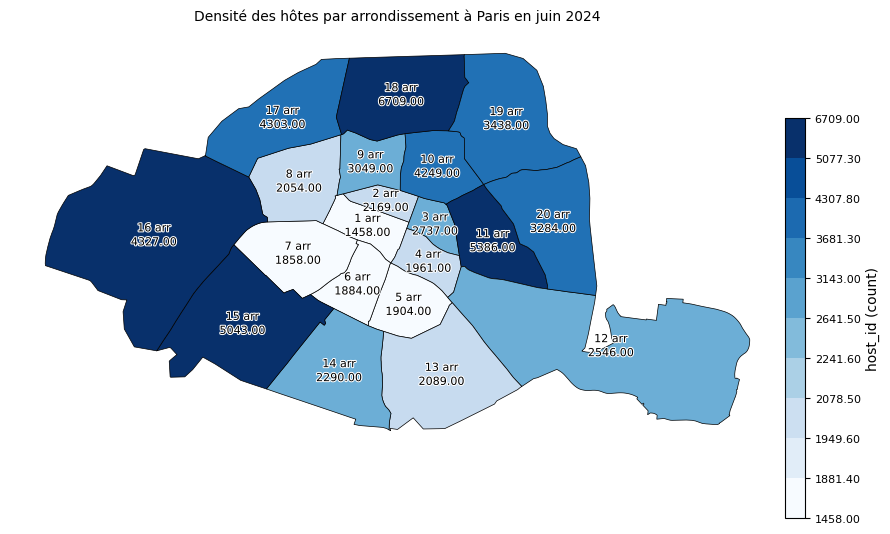

In [6]:
importlib.reload(geoplot)
from utils.geoplot import get_choropleth_map
get_choropleth_map(gdf_joined, 
            gdf_venues=None,
            gdf_map=gdf_map, 
            col="host_id", way="count",groupby="c_ar",
            title="Densité des hôtes par arrondissement à Paris en juin 2024",
            fig=None, subax=None, vmin=None, vmax=None,values=None,bins=None,  #oblig for subplots   
            scheme='quantile', k_quantile=10, cmap="Blues", # colors
            color_text="black", color_star="orange",

            save=True, loc=None, ym=None,# for automatic filename 
            output_folder=OUTPUT_FOLDER_MAP,filename=None
        )

## comparaison indépendente:

In [7]:
LOC="paris"
SUBTITLE_YM=["T1 2024","T2 2024", "T3 2024"]
YMS=["2403","2406", "2409"]

INPUT_FOLDER_GEO=Path("../data_geo/Q1Q2Q3")

# gdf map, gdf_venues
gdf_map=read_gdf('../data_map\paris_ar.gpkg')
gdf_venues=gpd.read_file("../data_geo\main_venues_JO.gpkg")

## group data
dict_gdf_joined={} 

for ym, subtitle_ym in zip(YMS, SUBTITLE_YM):
    path_gdf_joined=os.path.join(INPUT_FOLDER_GEO, f"listings_{LOC}{ym}_geo.gpkg")    
    gdf_joined=gpd.read_file(path_gdf_joined) 
    print(f"{subtitle_ym} len gdf :{len(gdf_joined)}， len host :{len(gdf_joined['host_id'].unique())}")    
    dict_gdf_joined[subtitle_ym]=gdf_joined
print(dict_gdf_joined.keys())

OUTPUT_FOLDER_MAP=Path("../output_map1/compa_indep")


T1 2024 len gdf :40865， len host :28104
T2 2024 len gdf :62738， len host :45846
T3 2024 len gdf :48064， len host :33668
dict_keys(['T1 2024', 'T2 2024', 'T3 2024'])


[INFO] cbar takes bounds: quantile!
✅ [SAVE] map saved to ..\output_map1\compa_indep\indep_comparaison_host_id_count_paris-T1 2024-T2 2024-T3 2024.jpg!


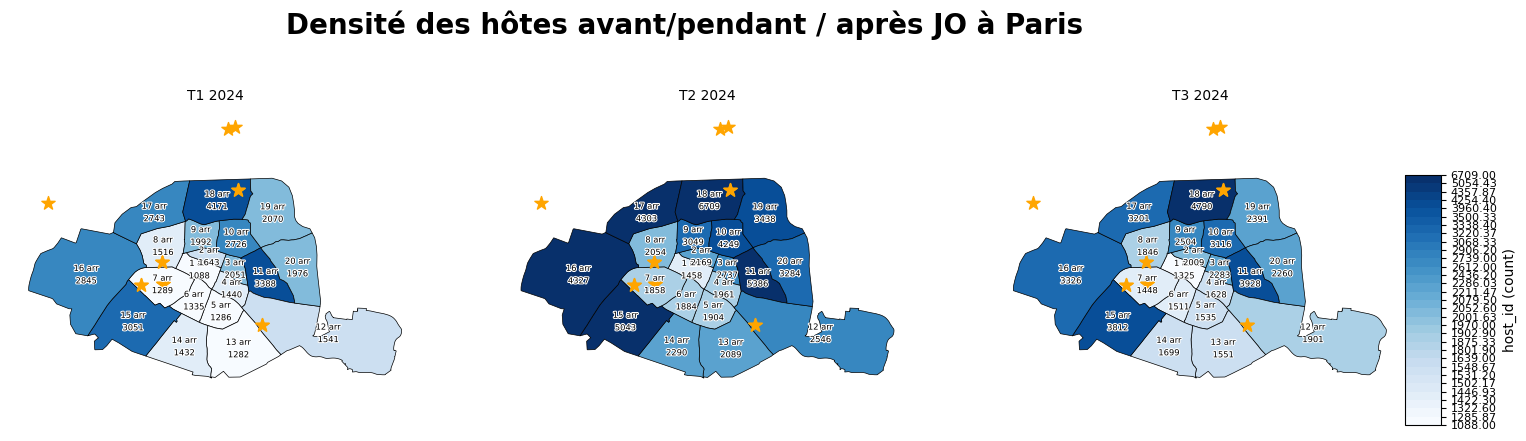

In [8]:
importlib.reload(geoplot)
from utils.geoplot import layout_comparison_indep, get_choropleth_map

layout_comparison_indep(dict_gdf_joined=dict_gdf_joined, 
                gdf_map=gdf_map,
                gdf_venues=gdf_venues,
                col="host_id", way="count", groupby="c_ar",
                suptitle="Densité des hôtes avant/pendant / après JO à Paris", 
                scheme="quantile", vmin=None, vmax=None, k_quantile=30, bins=None, cmap="Blues",
                color_text="black", color_star='orange',n_digit=0,
                loc="paris", # for filename
                n_axes=3, n_cols=3,#每行最多几张（列）
                save=True, output_folder=OUTPUT_FOLDER_MAP, filename=None)


[INFO] cbar takes bounds: quantile!
✅ [SAVE] map saved to ..\output_map1\compa_indep\indep_comparaison_price_mean_paris-T1 2024-T2 2024-T3 2024.jpg!


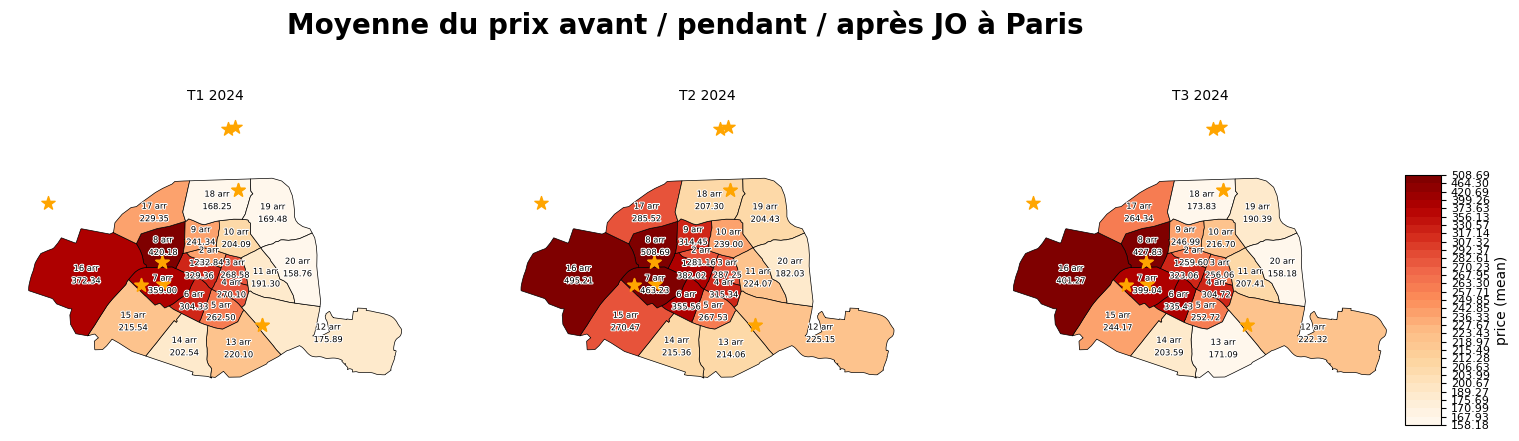

In [9]:
importlib.reload(geoplot)
from utils.geoplot import layout_comparison_indep, get_choropleth_map

layout_comparison_indep(dict_gdf_joined=dict_gdf_joined, 
                gdf_map=gdf_map,
                gdf_venues=gdf_venues,
                col="price", way="mean", groupby="c_ar",
                suptitle="Moyenne du prix avant / pendant / après JO à Paris", 
                scheme="quantile", vmin=None, vmax=None, k_quantile=30, bins=None, cmap="OrRd",#"viridis",#"OrRd",
                color_text="black", color_star='orange',n_digit=2,
                loc="paris", # for filename
                n_axes=3, n_cols=3,#每行最多几张（列）
                save=True, output_folder=OUTPUT_FOLDER_MAP, filename=None)


[INFO] cbar takes bounds: quantile!
✅ [SAVE] map saved to ..\output_map1\compa_indep\indep_comparaison_availability_90_mean_paris-T1 2024-T2 2024-T3 2024.jpg!


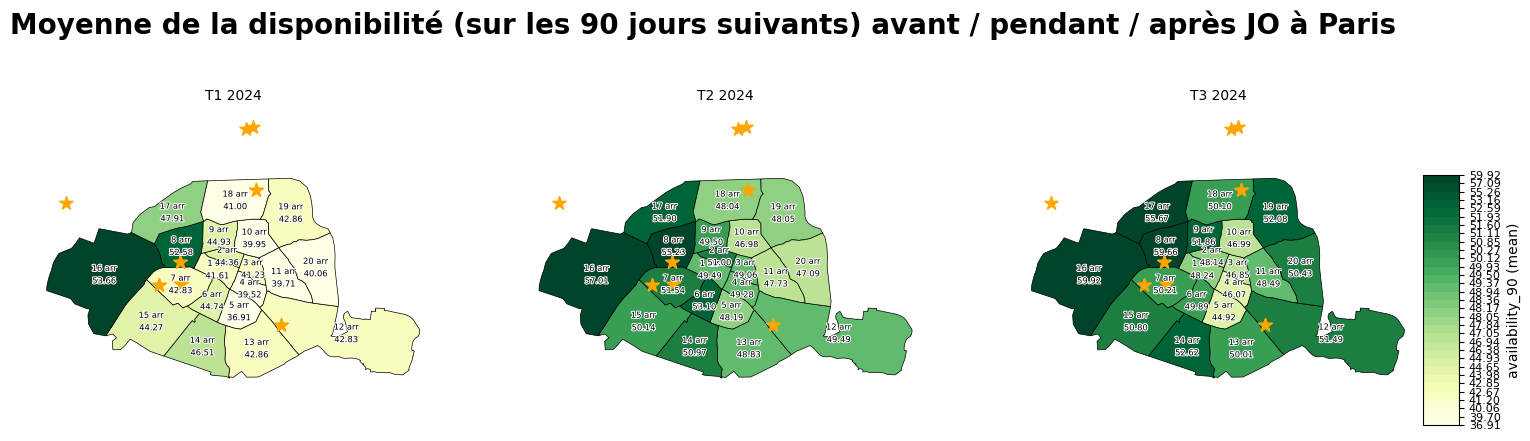

In [10]:
importlib.reload(geoplot)
from utils.geoplot import layout_comparison_indep, get_choropleth_map

layout_comparison_indep(dict_gdf_joined=dict_gdf_joined, 
                gdf_map=gdf_map,
                gdf_venues=gdf_venues,
                col="availability_90", way="mean", groupby="c_ar",
                suptitle="Moyenne de la disponibilité (sur les 90 jours suivants) avant / pendant / après JO à Paris",
                scheme="quantile", vmin=None, vmax=None, k_quantile=30, bins=None, cmap="YlGn",#"Blues",#"Blues",#"Greens",#"YlGnBu",# "BuPu"
                color_text="black", color_star='orange', n_digit=2,
                loc="paris", # for filename
                n_axes=3, n_cols=3,#每行最多几张（列）
                save=True, output_folder=OUTPUT_FOLDER_MAP, filename=None)


[INFO] cbar takes bounds: quantile!


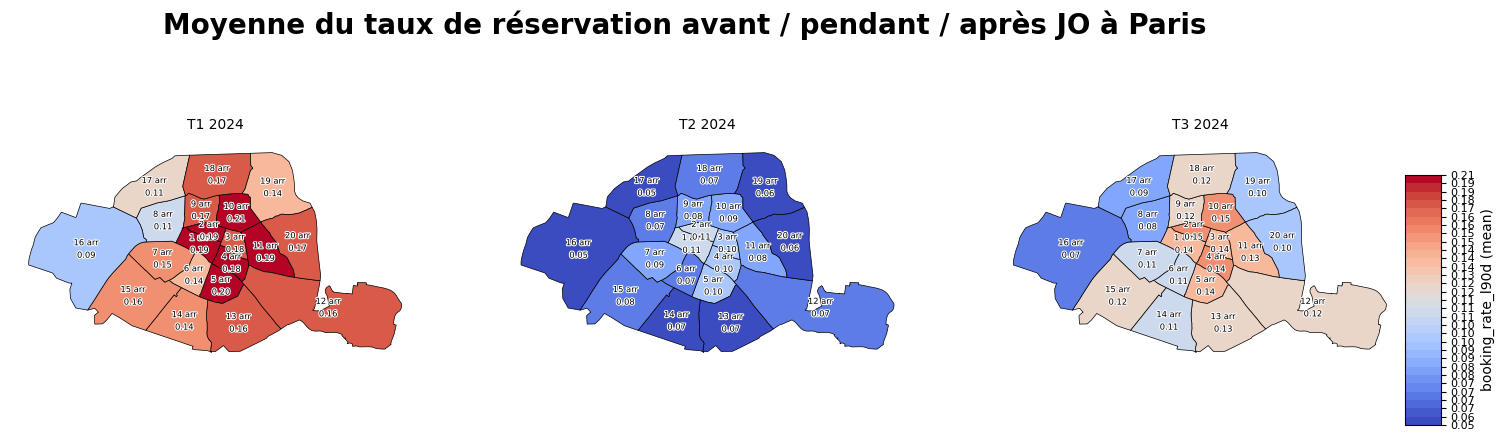

In [11]:
##booking 
importlib.reload(geoplot)
from utils.geoplot import layout_comparison_indep


layout_comparison_indep(dict_gdf_joined=dict_gdf_joined, 
                gdf_map=gdf_map,
                gdf_venues=None,
                col="booking_rate_l90d", way="mean", groupby="c_ar",
                suptitle="Moyenne du taux de réservation avant / pendant / après JO à Paris",
                scheme="quantile", vmin=None, vmax=None, k_quantile=30, bins=None, cmap="coolwarm",#"Blues",#"Blues",#"Greens",#"YlGnBu",# "BuPu"
                color_text="black", color_star='orange',
                loc="paris", # for filename
                n_axes=3, n_cols=3,#每行最多几张（列）
                save=False, output_folder=None, filename=None)


## gap

[INFO] cbar takes bounds: quantile!


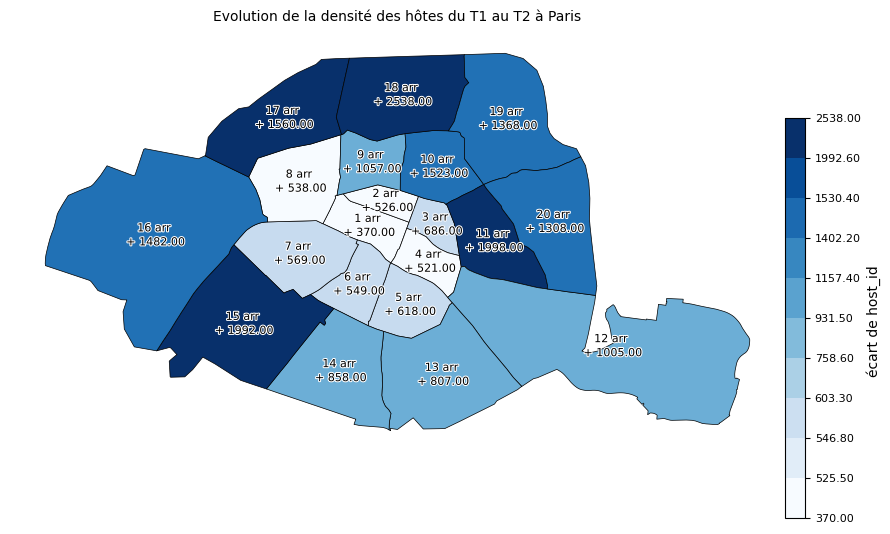

In [14]:
importlib.reload(geoplot)
from utils.geoplot import get_choropleth_map_gap

OUTPUT_FOLDER_MAP=Path("../output_map1/compa_gap")

get_choropleth_map_gap(dict_gdf_joined=dict_gdf_joined, 
            gap_between=['T1 2024','T2 2024'],
            gdf_map=gdf_map, 
            gdf_venues=None, 

            col='host_id', way="count", groupby="c_ar",
            title="Evolution de la densité des hôtes du T1 au T2 à Paris",
            
            add_buffer_m=None,
            fig=None, subax=None, vmin=None, vmax=None,values=None,bins=None,  #oblig for subplots   
            scheme='quantile', k_quantile=10, cmap="Blues", # colors
            color_text="black", color_star="orange",n_digit=2,

            save=False, loc=None, ym=None, # for filename
            output_folder=None,filename=None
        )


[INFO] cbar takes bounds: quantile!
✅ [SAVE] map saved to ..\output_map1\compa_gap\gap_comparaison_host_id_count_Paris-T1 2024-T2 2024-T3 2024.jpg!


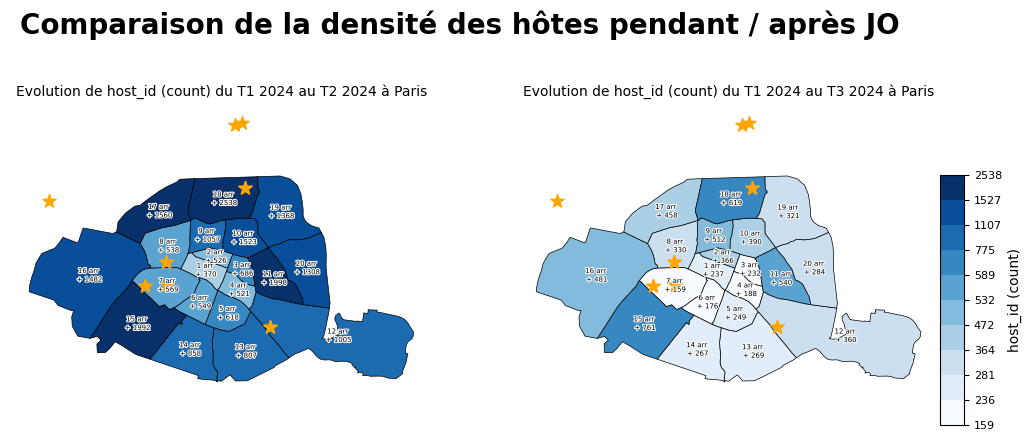

In [15]:
importlib.reload(geoplot)
from utils.geoplot import layout_comparison_gap
layout_comparison_gap(dict_gdf_joined, 
                gdf_map,
                gdf_venues=gdf_venues,add_buffer_m=None,
                gap_groups=[['T1 2024', "T2 2024"], ["T1 2024","T3 2024"]],
                col="host_id", way="count", groupby='c_ar',
                scheme="quantile", vmin=None, vmax=None, k_quantile=10, bins=None, cmap="Blues",
                color_text="black", color_star="orange", n_digit=0,
                suptitle='Comparaison de la densité des hôtes pendant / après JO', loc="Paris", # for filename
                n_axes=2, n_cols=2,#每行最多几张（列）
                save=True, output_folder=OUTPUT_FOLDER_MAP, filename=None)

[INFO] cbar takes bounds: quantile!


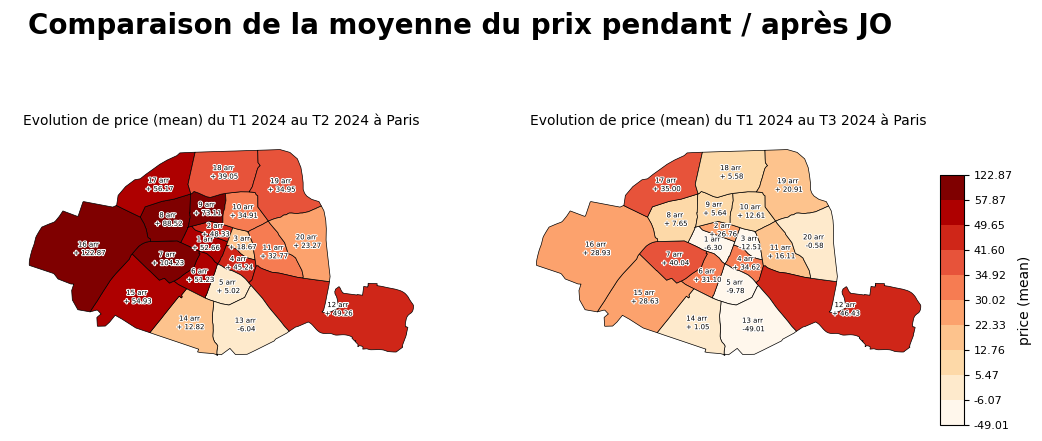

In [16]:
importlib.reload(geoplot)
from utils.geoplot import layout_comparison_gap
layout_comparison_gap(dict_gdf_joined=dict_gdf_joined, 
                gdf_map=gdf_map,
                gdf_venues=None,add_buffer_m=None,
                gap_groups=[['T1 2024', "T2 2024"], ["T1 2024","T3 2024"]],
                col="price", way="mean", groupby='c_ar',
                scheme="quantile", vmin=None, vmax=None, k_quantile=10, bins=None, cmap="OrRd",
                suptitle='Comparaison de la moyenne du prix pendant / après JO', loc="Paris", # for filename
                n_axes=2, n_cols=2,#每行最多几张（列）
                save=False, output_folder=None, filename=None)

[INFO] cbar takes bounds: quantile!
✅ [SAVE] map saved to ..\output_map1\compa_gap\gap_comparaison_availability_90_mean_Paris-T1 2024-T2 2024-T3 2024.jpg!


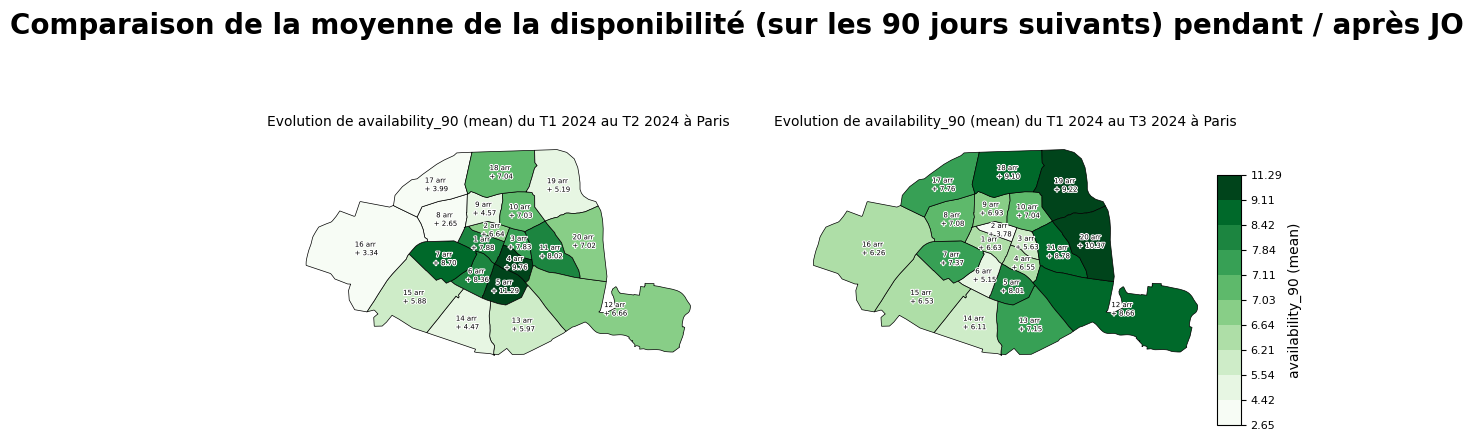

In [17]:
importlib.reload(geoplot)
from utils.geoplot import layout_comparison_gap
layout_comparison_gap(dict_gdf_joined, 
                gdf_map,
                gdf_venues=None,add_buffer_m=None,
                gap_groups=[['T1 2024', "T2 2024"], ["T1 2024","T3 2024"]],
                col="availability_90", way="mean", groupby='c_ar',
                scheme="quantile", vmin=None, vmax=None, k_quantile=10, bins=None, cmap="Greens",
                suptitle='Comparaison de la moyenne de la disponibilité (sur les 90 jours suivants) pendant / après JO', loc="Paris", # for filename
                n_axes=1, n_cols=2,#每行最多几张（列）
                save=True, output_folder=OUTPUT_FOLDER_MAP, filename=None)

In [ ]:
importlib.reload(geoplot)
from utils.geoplot import layout_comparison_gap
layout_comparison_gap(dict_gdf_joined, 
                gdf_map,
                gdf_venues,add_buffer_m=None,
                gap_groups=[['T1 2024', "T2 2024"], ["T1 2024","T3 2024"]],
                col="host_id", way="count", groupby='c_ar',
                scheme="quantile", vmin=None, vmax=None, k_quantile=10, bins=None, cmap="plasma_r",
                suptitle='Comparaison de la densité des hôtes avant / après JO', loc="paris", # for filename
                n_axes=2, n_cols=2,#每行最多几张（列）
                save=False, output_folder=None, filename=None)

,c_ar,mean_x,mean_y,gap
0,1.0,329.360294,382.016461,52.656167
1,2.0,232.835058,281.163209,48.328151
2,3.0,268.575329,287.250274,18.674945
3,4.0,270.097222,315.339623,45.242400
4,5.0,262.501555,267.525735,5.024180


✔ [SAVE]  choropleth gap map saved to ..\output_map\Q1Q2Q3\gap_map_price_mean_paris2403-2406.jpg!


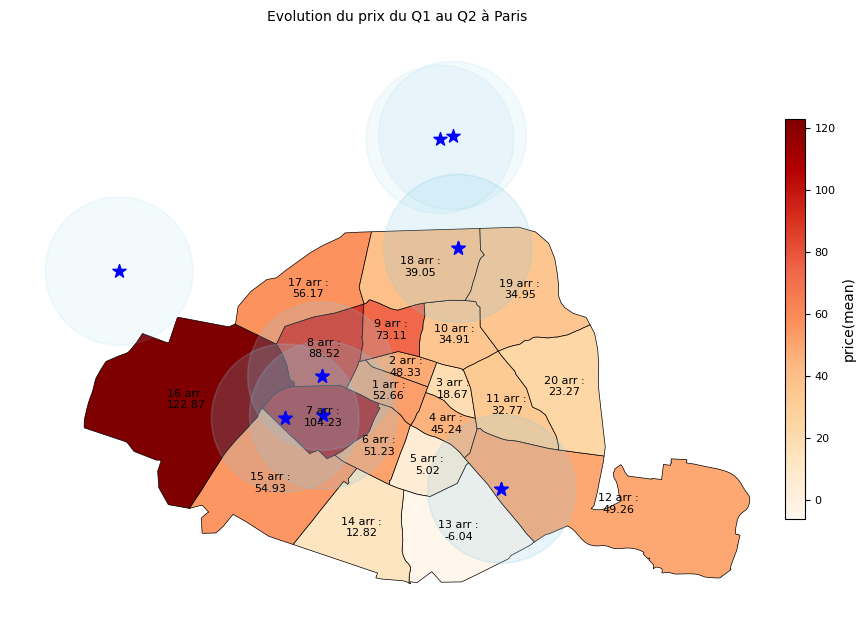

In [37]:
importlib.reload(geoplot)
from utils.geoplot import get_choropleth_map_gap

get_choropleth_map_gap(dict_gdf_joined=dict_gdf_joined, 
            gap_between=["2403",'2406'],
            gdf_map=gdf_map, 
            gdf_venues=gdf_venues,
            add_buffer_m=2000,
            col='price', way="mean", groupby="c_ar",
            cmap='OrRd',
            subtitle="Evolution du prix du Q1 au Q2 à Paris",
            fig=None, subax=None, vmin=None, vmax=None,# optionel
            save=True, loc=LOC, ym=None, 
            output_folder=OUTPUT_FOLDER_MAP,filename=None
        )


,c_ar,mean_x,mean_y,gap
0,1.0,41.614890,49.491084,7.876194
1,2.0,44.357882,51.000922,6.643040
2,3.0,41.225744,49.056631,7.830888
3,4.0,39.515278,49.278429,9.763152
4,5.0,36.905132,48.191176,11.286044


✔ [SAVE]  choropleth gap map saved to ..\output_map\Q1Q2Q3\gap_map_availability_90_mean_paris2403-2406.jpg!


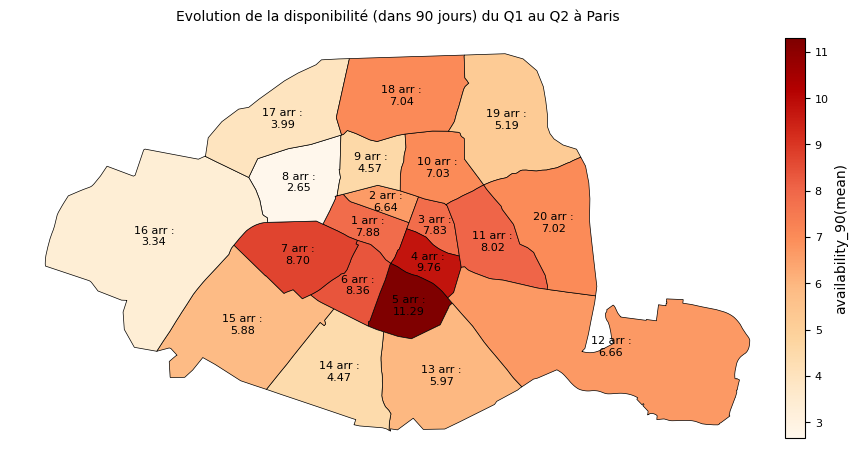

In [ ]:
get_choropleth_map_gap(dict_gdf_joined=dict_gdf_joined, 
            gap_between=["2403",'2406'],
            gdf_map=gdf_map, 
            col='availability_90', way="mean", groupby="c_ar",
            subtitle="Evolution de la disponibilité (dans 90 jours) du Q1 au Q2 à Paris",
            fig=None, subax=None, vmin=None, vmax=None,# optionel
            save=True, loc=LOC, ym=None, 
            output_folder=OUTPUT_FOLDER_MAP,filename=None
        )


## gap comparaison

[INFO] compa gap layout: 1 rows x 3 cols



,c_ar,count_x,count_y,gap
0,1.0,1458,1088,-370
1,2.0,2169,1643,-526
2,3.0,2737,2051,-686
3,4.0,1961,1440,-521
4,5.0,1904,1286,-618


,c_ar,count_x,count_y,gap
0,1.0,1458,1325,-133
1,2.0,2169,2009,-160
2,3.0,2737,2283,-454
3,4.0,1961,1628,-333
4,5.0,1904,1535,-369


[CHECK] -2538.00-0.00=> cmap <matplotlib.colors.LinearSegmentedColormap object at 0x000002AEE8D79C00>
[CHECK] 1458.00-6709.00=> cmap OrRd
✅ [SAVE] comparasion gap map saved to ..\output_map\Q1Q2Q3\compa_gap\gap_comparaison_host_id_count_paris2403-2406-2409.jpg!


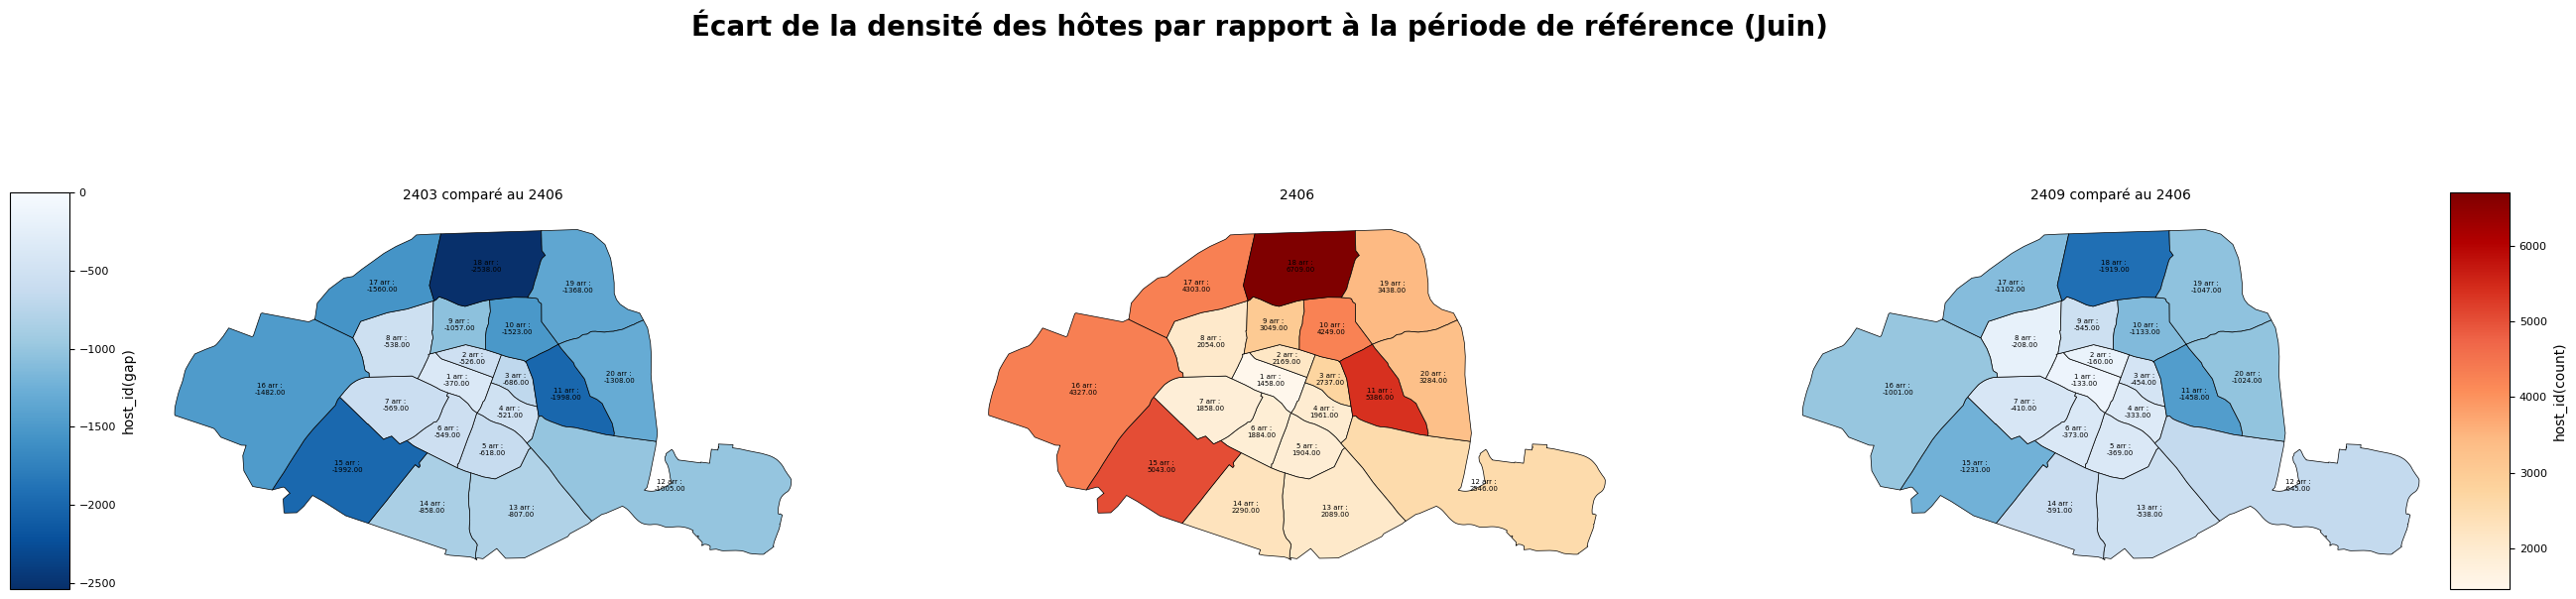

In [31]:
importlib.reload(geoplot)
from utils.geoplot import layout_comparison_gap
OUTPUT_FOLDER_MAP=Path("../output_map/Q1Q2Q3")

layout_comparison_gap (dict_gdf_joined=dict_gdf_joined, 
                       gdf_map=gdf_map,
                       gdf_venues=None,
                        ym_key="2406",
                        col="host_id", way="count", groupby="c_ar",
                        n_axes=3, n_cols=3,
                        suptitle="Écart de la densité des hôtes par rapport à la période de référence (Juin)", 
                        loc=LOC,#for filename
                        save=True, output_folder=OUTPUT_FOLDER_MAP/'compa_gap',
                        filename=None
                        )